# EDA & ML for medical ensurance costs

# EDA

## PASO 1: **Imports**

In [1]:
# Imports de librearías:
## Cálculos y gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
## from sklearn.model_selection import train_test_split
### Modelado
from sklearn.linear_model import LogisticRegression
### Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
### Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
## from tqdm import tqdm
import warnings

In [2]:
# Read csv:
df = pd.read_csv("../data/raw/medical_ensurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## PASO 2: **Data & Problem Description**

###  **Problem desciption**

* **Objetivo:** Predecir el coste del seguro médico de una persona
* **Planteamiento:** La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, **cuál va a ser la prima (coste) que debe asumir cada uno de ellos**. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

###  **Data Variables**

> 1. ``age``. Edad del beneficiario principal (numérico)
> 2. ``sex``. Género del beneficiario principal (categórico)
> 3. ``bmi``. índice de masa corporal (numérico)
> 4. ``children``. Número de niños/dependientes cubiertos por un seguro médico (numérico)
> 5. ``smoker``. ¿Es fumador? (categórico)
> 6. ``region``. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
> 7. ``charges``. Prima del seguro médico (numérico)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 1338 filas y 16 columnas  
> * Los datos que aporta el datset son 4 columnas de tipo numérico (enteros y decimales) y 3 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(2), int64(2), object(3)``  

### **Variable target** 
> * ``charges``, variable target escogida ya que nos indica el valor prima del seguro médico que ya tenía cada persona.

In [4]:
df['charges'].max()

np.float64(63770.42801)

In [5]:
df[df['charges']>30000]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1308,25,female,30.200,0,yes,southwest,33900.65300
1313,19,female,34.700,2,yes,southwest,36397.57600


## PASO 3: **Limpieza de datos**

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
# Compruebo si hay datos nulos (datos faltantes)
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
# Print df de las columnas duplicadas para ver la fila duplicada:
df_dupl = df[df.duplicated(subset=df.columns, keep=False)]
df_dupl

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


**Conclusión de la limpieza de datos:**

> 1. VAOLRES NULOS Y DUPLICADOS:
> * Las columnas no contienen valores nulos y hay solamente una fila duplicada

## PASO 4: **Análisis de las variables:**

### **ANÁLISIS UNIVARIANTE**

##### Vars Numéricas

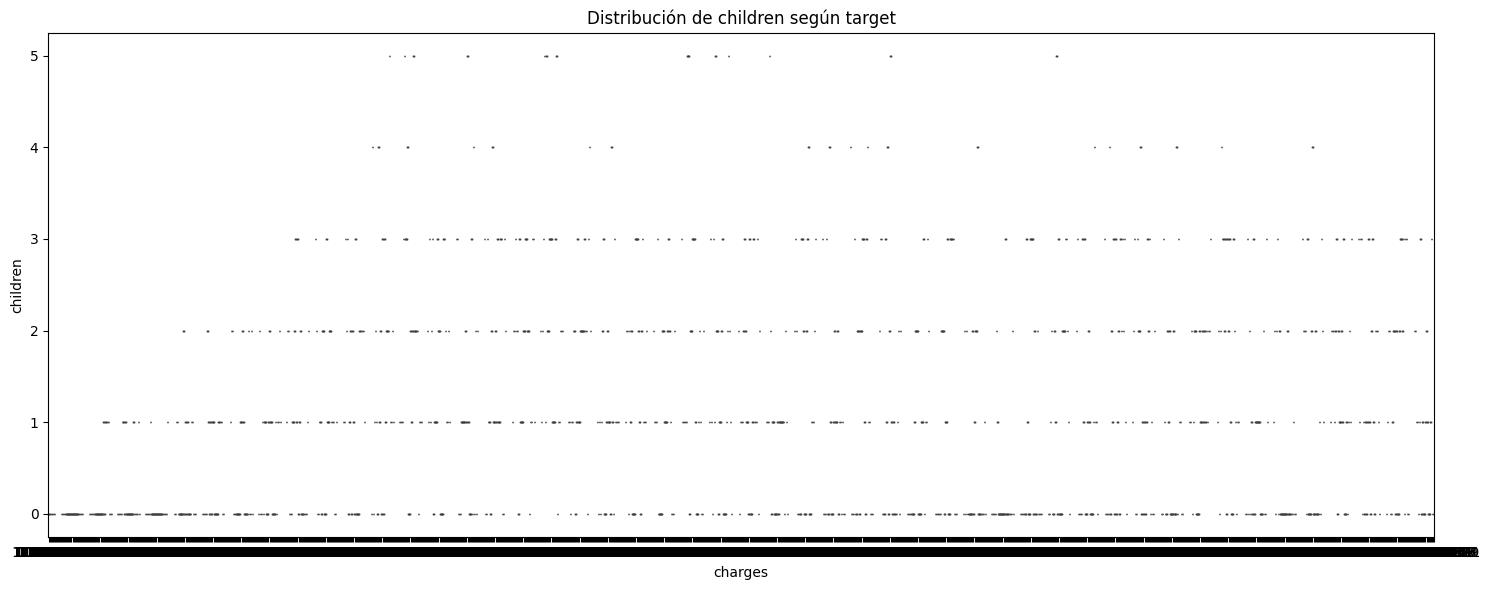

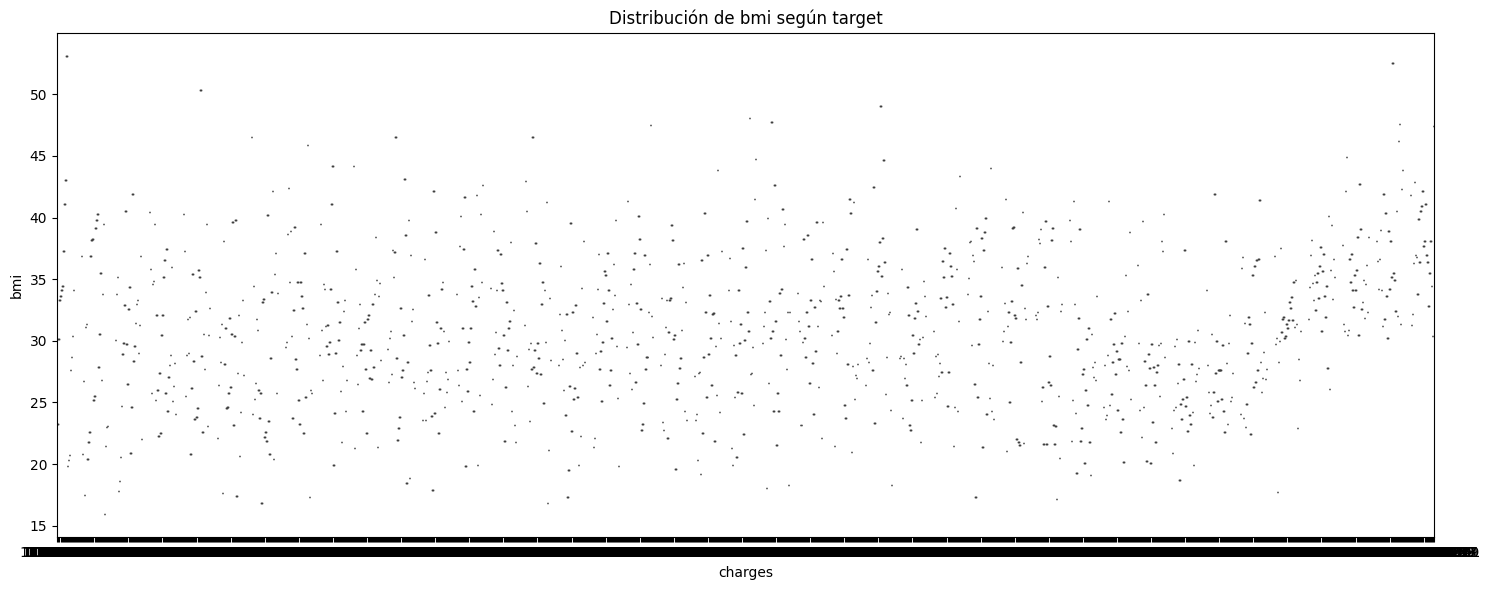

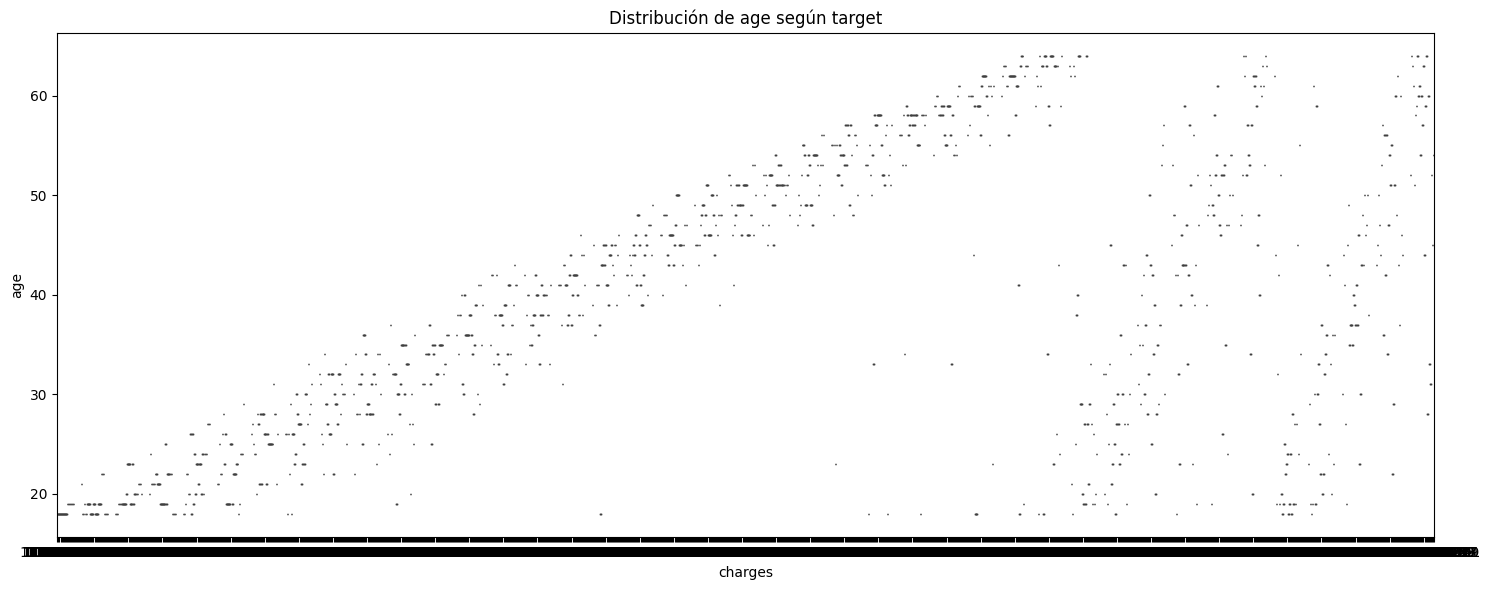

In [ ]:
# REHACER, ESTOS GRAFICOS NO TIENE SENTIDO, NO APORTAN
# numeric_cols = ["children", "bmi", "age"]

# for columna in numeric_cols:
#     plt.figure(figsize=(15,6))
#     sns.boxplot(data=df, x='charges', y=columna)
#     plt.title(f"Distribución de {columna} según target")
#     plt.tight_layout()
#     plt.show()

##### Vars Categóricas

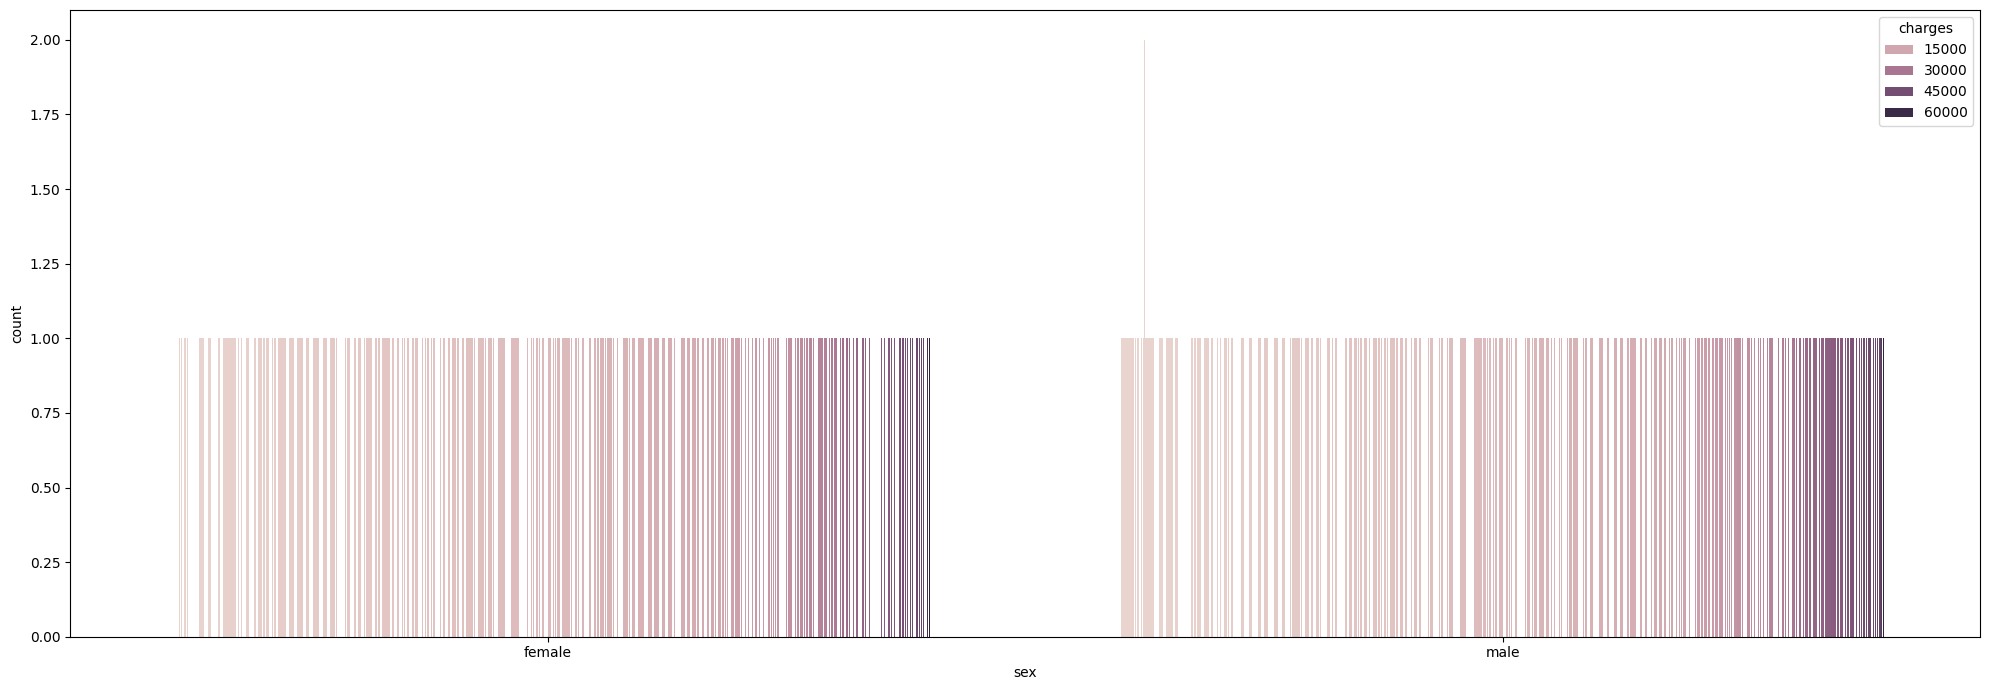

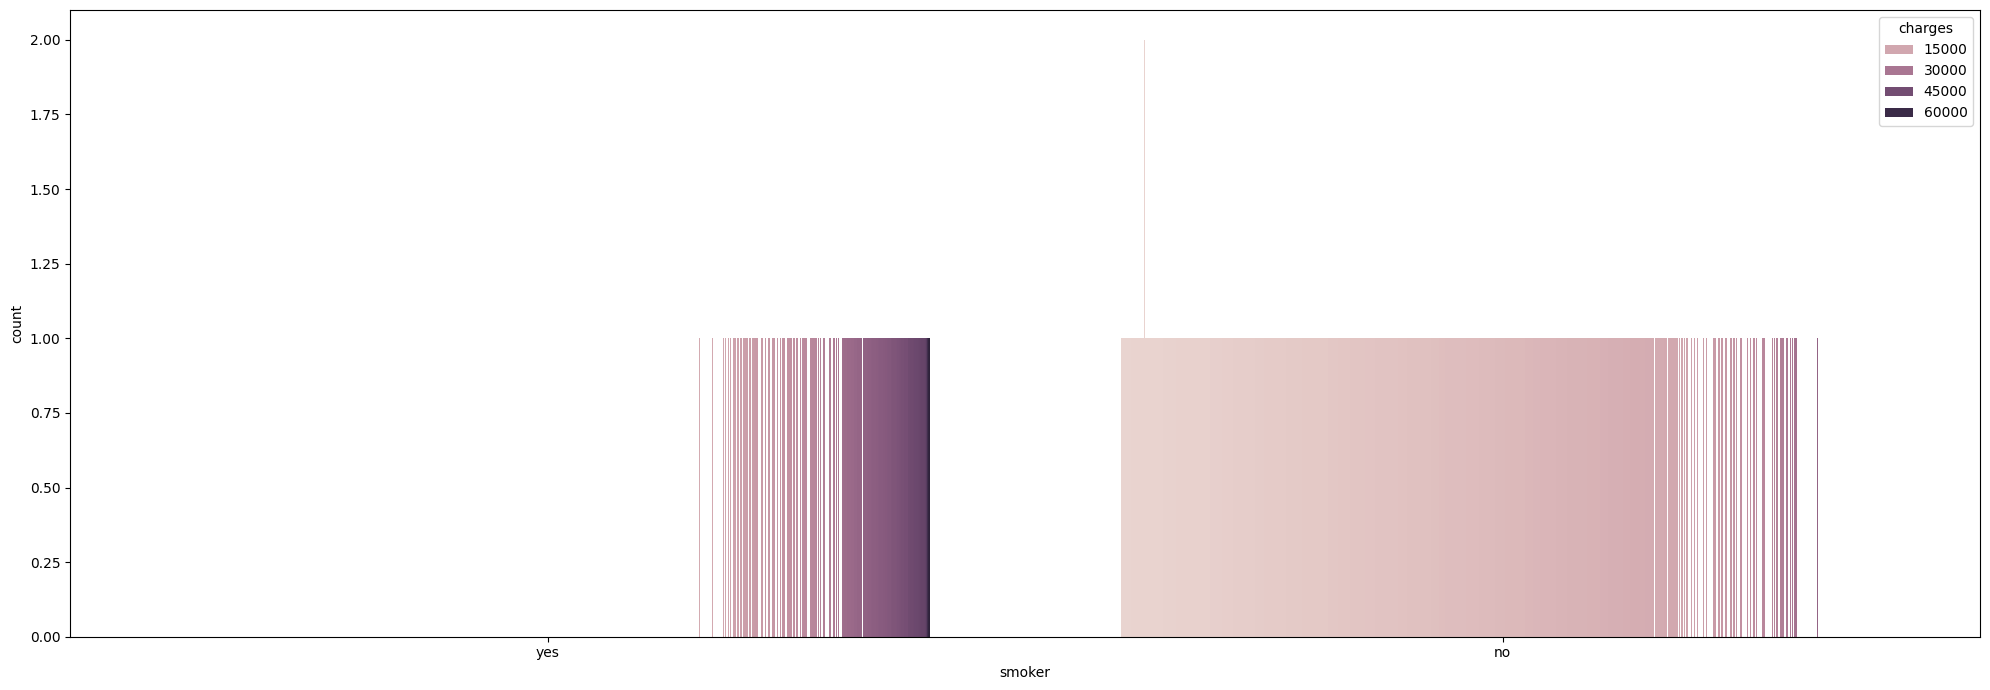

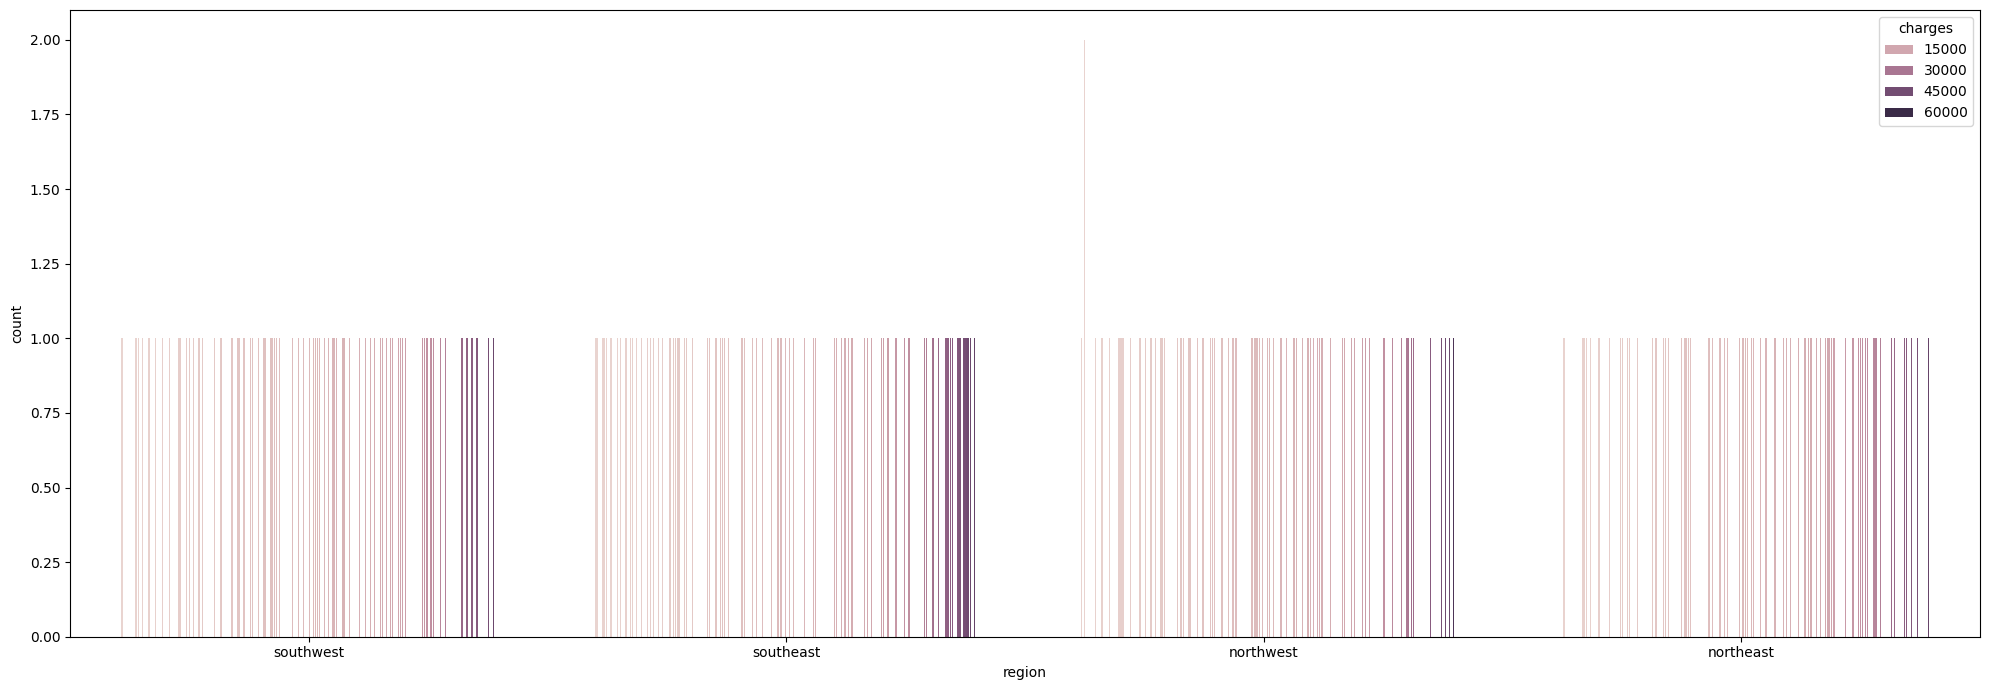

In [ ]:
# categorical_cols = ["sex", "smoker", "region"]
# # Bucle para crear gráficos comparando la variable categórica target con el resto de variables 
# for column in categorical_cols:
#     fig, axis = plt.subplots(figsize=(20, 7))
#     sns.countplot(data=df, x=column, hue="charges")
#     plt.tight_layout()
#     plt.show()

### **ANÁLISIS MULTIVARIANTE**

##### Factorización

In [11]:
df_factorize = df.copy()

In [12]:
df_factorize['smoker_y'] = pd.factorize(df['smoker'])[0]
df_factorize['region_y'] = pd.factorize(df['region'])[0]
df_factorize['sex_y'] = pd.factorize(df['sex'])[0]

In [13]:
# No recuerdo que hacia include=['number']
df_numerico = df_factorize.select_dtypes(include=['number'])

##### Analisis Vars Numérico - Categórico 

CORRELACIÓN - HEAT MAPS

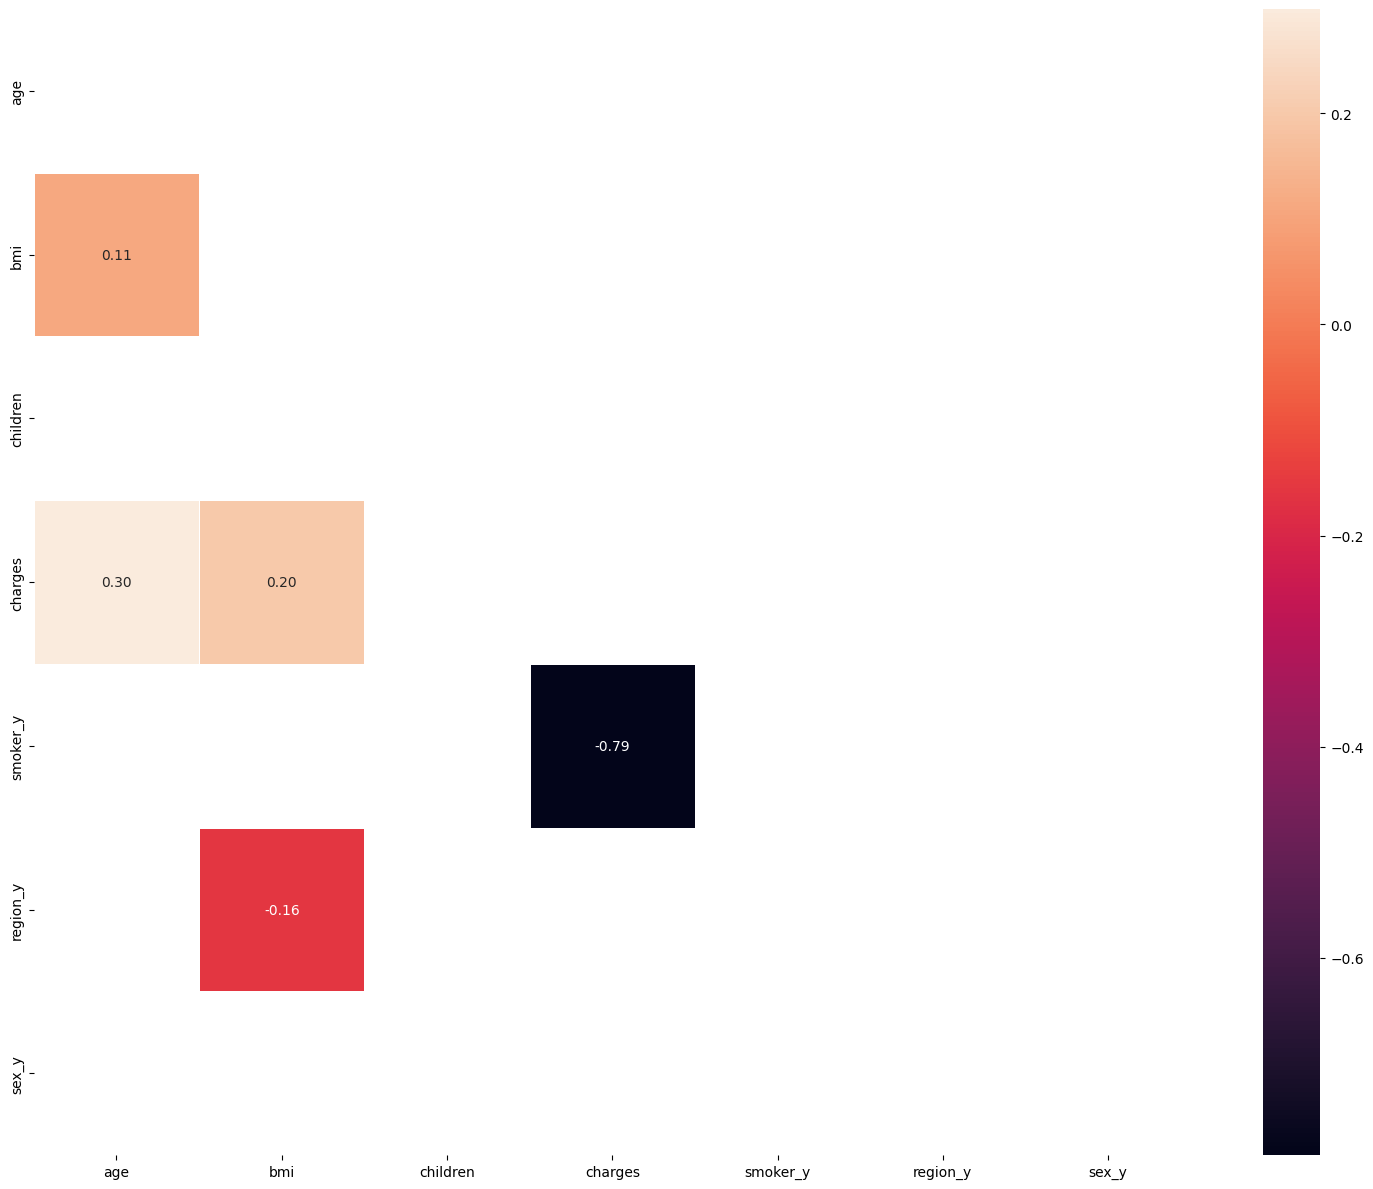

In [14]:
corr = df_numerico.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**Conclusiones:**
Eliminar columnas x - Después hacer OTRO HEATMAP PARA VER NUEVAS CORRELACIONES

In [15]:
# df_numerico.drop(columns=[''])

## PASO 5: **Split Data: tain & test**

In [16]:
# X = df_droping.drop("y", axis=1)
# y = df_droping[ "y"]

# # Instancia de: from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

## PASO 6: **Encoding**

### **Guardado de data codificada**

In [17]:
# Utilizando Pickle (que nos permite guardar objetos de Python)
# with open('/workspaces/betaniammc-machine-learning/models/logistic-regression-label-encoder.pkl', 'wb') as file:
#     pickle.dump(label_encoder_contact, file)

### **Escalado de normalización**

In [18]:
norm_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler

NameError: name 'StandardScaler' is not defined

### **Generar modelo de entrenamiento de datos (con los datos ya escalados)**

In [ ]:
# Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)
model = LogisticRegression(random_state=18)

# Entrena
model.fit(X_train_cat_le_scaled, y_train)

# ML

## PASO x: **Linear Regression Model**

APUNTES: Cómo funciona la R.Lineal / R. Logística
| Aspecto           | Regresión Logística                |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Clasificación                      |
| Salida del modelo | Probabilidad entre 0 y 1           |
| Toma de decisión  | Por umbral (e.g. 0.5)              |
| Nombre confuso    | Proviene de la estadística clásica |

### **Definiciñon de variables para el modelo:**

1. VAR. DEPENDIENTE:
> * N
2. VARS INDEPENDIENTES:
> * N

### **Paso 1_Import train and test data or Split**

### **Paso 2_Iniciacion y entrenamiento del modelo**

### **Paso 3_Predicción del modelo**

In [ ]:
# pREDECIR EL CONJUNTO DE DATOS TEST
y_pred = model.predict(X_test_cat_le_scaled)
y_pred

In [ ]:
# y_pred = 
# model_accuracy -> accuracy_score(y_test,y_pred)

In [ ]:
# # Confusion matrix:

# titanic_cm = confusion_matrix(y_test, y_pred)

# # Dibujaremos esta matriz para hacerla más visual
# df_cm = pd.DataFrame(titanic_cm)

# plt.figure(figsize=(3, 3))
# sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.show()


**Observaciones:**
> * TP (True Positive)
> * TN (True Negative)
> * FP (False Positive)
> * FN (False Negative)

### **Umbral de decisión:**

In [ ]:
# # predict() from scikit.learn sets 0.5 umbral to convert the predicted probabilities into binary labels
# # Suponiendo que 'model' es tu modelo de regresión logística ya entrenado
# y_proba = model.predict_proba(X_test)

# # Suponiendo que deseas ajustar el umbral a 0.3
# threshold = 0.3
# y_pred_threshold = np.where(y_proba[:, 1] > threshold, 1, 0)

# # Evaluar el rendimiento con el nuevo umbral
# accuracy_score(y_test, y_pred_threshold)


### **Optimicaxion de resultados:**

##### **Hiperparémetros:**

> * ``penalty``, 
> * ``C``, 
> * ``solver``, 
> * ``max_iter``, 
> * ``random_state``, 

In [ ]:
# Definición hiperparams
# GridSearchCV()
# Metodo .fit(X_train,y_train) -> determinates penalty¿?
# grid -> accurary - model accuracy comparation
# model_random_search -> nueva hiperparametrizacion para entrenar el modelo